# <font size="6" color="blue"><b>第 11 章：模組(Modules)與套件(Packages)</font></b>  
此版本更新於 2026/5/28

# 模組(Module)與import陳述式
* 模組只是一個存有任意的 Python 程式碼的檔案。你不需要做任何特別的事情，任何Python程式碼都可以當成模組被其他的程式碼使用。
* 藉著使用Python的`import`陳述式來引用其他模組的程式碼，它可以讓你的程式使用被匯入的模組裡面的程式碼與變數。

# 匯入模組
* import陳述式最簡單的用法是`import module`，其中的module是其他的Python檔名，不包括.py副檔名。
* 在import陳述式之後，主程式可以使用fast.py裡面的所有東西，只要在它們的名稱前面加上`fast.`即可。

In [1]:
# 需與fast.py放在同一個目錄裡面
import fast   # 匯入fast模組

place = fast.pick()   # 執行fast模組中的pick()函式
print("Let's go to", place)

McDonals
Let's go to KFC


* 使用別名 f 取代fast模組

In [8]:
import fast as f
place = f.pick()
print("Let's go to", place)

Let's go to Berger King


* 只從模組匯入你想要的函式

In [9]:
from fast import pick
place = pick()
print("Let's go to", place)

Let's go to Moses


* 用別名who_cares取代pick

In [10]:
from fast import pick as who_cares
place = who_cares()
print("Let's go to", place)

Let's go to Wendys


# 套件 (Package)
* 為了讓Python應用程式擴展得更大，你可以將模組組織為檔案，以及稱為套件（package）的模組層次結構。
* 套件只是存有 .py 檔案的資料夾，你也可以在它們裡面加入更深的一層的資料夾。
* 製作一個名為 choices 的子資料夾，並且在裡面放入兩個模組，fast.py 與 advice.py。
* 各個模組都有一個回傳字串的函式

In [6]:
# from choices 會讓 Python 尋找名為 choices 的目錄，從你目前的目錄底下開始找起。
# 它會在 choices 裡面尋找 fast.py 與 advice.py 檔案。
from choices import fast, advice

print("Let's go to", fast.pick())
print("Should we take out?", advice.give())

Let's go to KFC


AttributeError: module 'choices.advice' has no attribute 'give'

# 模組搜尋路徑
* Python 會在你目前的資料夾尋找子資料夾 choices 及其模組。事實上，它也會尋找其他地方，你可以控制這件事。
* 若要查看 Python 解譯器會尋找的所有地方，你可以匯入標準的 sys 模組，並使用它的 path 串列。
* 這個串列裡面有一系列的字典名稱與 ZIP 歸檔檔案，Python 會依序在它們裡面尋找要匯入的模組。

In [16]:
import sys
for place in sys.path:
    print(place)

c:\Users\Jason\anaconda3\python312.zip
c:\Users\Jason\anaconda3\DLLs
c:\Users\Jason\anaconda3\Lib
c:\Users\Jason\anaconda3

c:\Users\Jason\anaconda3\Lib\site-packages
c:\Users\Jason\anaconda3\Lib\site-packages\win32
c:\Users\Jason\anaconda3\Lib\site-packages\win32\lib
c:\Users\Jason\anaconda3\Lib\site-packages\Pythonwin
c:\Users\Jason\anaconda3\Lib\site-packages\setuptools\_vendor


# 絕對匯入
* 在截至目前為止的範例中，我們都從這些地方匯入自己的模組：目前的資料夾、子資料夾 choices、Python 標準程式庫。
* 這些做法都不會造成問題，除非本地模組的名稱與標準模組的一樣。名稱一樣時如何選擇？
* Python 支援絕對與相對匯入。截至目前為止的範例都是絕對匯入。
* 如果你在搜尋路徑裡面的各個資料夾中輸入 import rougarou，Python 會尋找一個稱為 rougarou.py 的檔案（模組），或一個稱為 rougarou 的資料夾（套件）。

# 相對匯入
* 如果 rougarou.py 與呼叫的程式在同一個資料夾，你可以用 from . import rougarou 從相對於你的位置匯入它。
* 如果它在你上面的資料夾：from .. import rougarou。
* 如果它在名為 creatures 的同層（sibling）資料夾，呼叫 from ..creatures import rougarou。


# 名稱空間套件
* 你也可以用名空間套件（namespace package）將一個套件拆到多個資料夾。
* 假如你想要做一個稱為 critters 的套件，並且在裡面放入各種危險生物的 Python 模組（無論是真的還是虛構的，應該有背景資訊與保護提示）。
* 這個套件可能會隨著時間的推移而愈來愈大，所以你想要按照地點將它們細分。
* 一種做法是在 critters 底下加入地點子套件，並且將既有的 .py 模組檔案放在它們底下，但是這樣子會破壞匯入它們的其他模組。
* 假設最初的檔案布局是這樣子：
critters  
 └── rougarou.py  
 └── wendigo.py  

* 匯入這些模組的做法通常是：from critters import wendigo, rougarou
* 如果我們決定加入 US 地點 north 與 south，檔案與資料夾是：
north  
 └── critters  
      └── wendigo.py  
south  
 └── critters  
      └── rougarou.py  

* 如果 north 與 south 都在模組搜尋路徑裡面，你可以匯入這些模組，彷彿它們仍然在單一資料夾套件一般：  
from critters import wendigo, rougarou

# 模組 vs. 物件
* 何時該將程式碼放入模組，何時該放入物件？
* 模組與物件有很多相似之處，thing.stuff 可以用來存取名為 thing，並且有一個內部值 stuff 的物件和模組。
* stuff 可能是在模組或類別被建立出來的時候定義的，也有可能是稍後再指派的。
* 在模組裡面的所有類別、函式與全域變數都可以在外面使用。
* 物件則可以使用 property 與（__...）名稱格式來隱藏或控制對於資料屬性的存取。

In [23]:
# 你的程式匯入的任何模組都只有一個複本，即使你多次匯入它。
# 它不會影響 Python 的 math 模組。你只是修改了呼叫方匯入的math模組複本中的pi值而已。
import math
print(math.pi)
math.pi = 3.0
print(math.pi)

3.0
3.0


# Housing Price Dataset
https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download
The dataset has 13 features and 545 samples.

# 套件1: Pandas 資料讀取與基礎探索
* pandas 是 Python 中最核心的資料分析與處理套件，專門用來處理表格型態的資料（類似 Excel 試算表）。
* 在資料科學欄位中，我們習慣將 pandas 匯入並縮寫為 pd。
* Pandas 的核心資料結構為 DataFrame（二維表格）與 Series（一維欄位）。

# 匯入 Pandas 與讀取 CSV 檔案
* 使用 import pandas as pd 匯入套件。
* 藉著使用 pd.read_csv('檔案名稱.csv') 函式，可以快速將 CSV 檔案載入並轉換為 DataFrame 物件。
* 讀取後，通常會使用 .head() 方法來預覽前幾筆資料，確保資料正確載入。

In [ ]:
import pandas as pd

# 讀取 CSV 檔案
df = pd.read_csv('Housing.csv') # df 為 DadaFrame

# 顯示前 5 筆資料預覽
print("--- 前 5 筆房屋資料 ---")
df.head()

--- 前 5 筆房屋資料 ---


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# 檢視資料結構與型態
* df.shape 是一個屬性（不需要加括號），用來顯示資料的（列數, 欄位數）。
* df.info() 則會列出所有欄位的名稱、非空值數量（Non-Null Count）以及資料型態（如 int64 數字或 object 字串）。
* 透過 .info() 可以幫助我們快速診斷資料集是否有缺失值。

In [3]:
# 1. 查看資料集的形狀（列數、欄位數）
print(f"資料集的形狀為：{df.shape}")

# 2. 檢視詳細欄位資訊
print("\n--- 資料詳細結構 ---")
df.info()

資料集的形狀為：(545, 13)

--- 資料詳細結構 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# 數值欄位的統計摘要
* df.describe() 可以針對資料集中所有「數值型態」的欄位進行自動統計。
* 它會計算出每一欄的總計數（count）、平均值（mean）、標準差（std）、最小值（min）、最大值（max）以及三個四分位數（25%, 50%, 75%）。
* 這能讓分析人員在第一時間掌握資料的分配狀況（例如房價、面積的區間）。

In [4]:
# 顯示數值欄位的統計特徵描述
print("--- 數值欄位統計描述 ---")
df.describe()

--- 數值欄位統計描述 ---


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# 類別型欄位的次數統計
* 對於非數值（文字型）的欄位，如 furnishingstatus（裝潢狀態：裝潢、半裝潢、未裝潢）。
* 我們可以使用 .value_counts() 方法，快速計算各個類別在資料集中出現的次數。

In [10]:
# 統計裝潢狀態的類別分佈
print("--- 房屋裝潢狀態統計 ---")
print(df['furnishingstatus'].value_counts())

--- 房屋裝潢狀態統計 ---
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64


# 基礎資料選取
* 選取單一欄位：使用 df['欄位名稱']，這會回傳一個 Series 物件。
* 選取多個欄位：使用 df[['欄位A', '欄位B']]（注意裡面必須是一個包含欄位名稱的 list 中括號）。

In [21]:
# 選取單一欄位（例如：房價）
prices = df['price']

# 選取多個相關欄位（例如：房價、面積與房間數）
sub_table = df[['price', 'area', 'bedrooms']]
print("--- 選取特定欄位後的資料 ---")
sub_table.head()

--- 選取特定欄位後的資料 ---


,price,area,bedrooms
0,13300000,7420,4
1,12250000,8960,4
2,12250000,9960,3
3,12215000,7500,4
4,11410000,7420,4


* 將符合「面積 6000 以上」且「房間 3 間以上」的資料篩選出來。
* 接著直接對篩選後的 DataFrame 呼叫 .sort_values() 進行排序，最後再導出存檔。

In [ ]:
import pandas as pd

# 1. 讀取原始 Housing.csv 資料
df = pd.read_csv('Housing.csv')

# 2. 設定篩選條件：面積 (area) >= 6000 且 房間數 (bedrooms) >= 3
condition = (df['area'] >= 6000) & (df['bedrooms'] >= 3)
filtered_df = df[condition]

# 3. 排序資料：依據房價 (price) 從便宜到貴（遞增排序）
# ascending=True 代表由小到大排序
sorted_df = filtered_df.sort_values(by='price', ascending=True)

# 顯示篩選且排序後的前 5 筆預覽（注意 price 欄位會從小到大排列）
print("--- 篩選並完成排序（房價由便宜到貴）的前 5 筆資料 ---")
sorted_df[['price', 'area', 'bedrooms', 'furnishingstatus', "hotwaterheating"]].head()

--- 篩選並完成排序（房價由便宜到貴）的前 5 筆資料 ---


,price,area,bedrooms,furnishingstatus,hotwaterheating
483,2940000,6615,3,semi-furnished,no
452,3150000,9000,3,semi-furnished,no
432,3290000,6060,3,furnished,no
393,3500000,7424,3,unfurnished,no
403,3500000,12944,3,unfurnished,no


In [24]:
# 4. 將排序後的結果存檔為新的 CSV 檔案
sorted_df.to_csv('Housing_filtered_sorted.csv', index=False)

print("資料已成功篩選、排序，並存檔至 'Housing_filtered_sorted.csv'！")

資料已成功篩選、排序，並存檔至 'Housing_filtered_sorted.csv'！


# 套件2: NumPy 陣列運算與資料處理
* NumPy（Numerical Python）是 Python 科學計算的核心套件，也是 Pandas、Scikit-learn 等資料科學套件的底層基礎。
* 在 Python 中，我們習慣將 numpy 匯入並縮寫為 np。
* NumPy 的核心資料結構為 ndarray（多維陣列）。與 Python 原生的 list 相比，NumPy 陣列具有高效的記憶體管理與向量化平行運算（Vectorization）能力，能大幅提升大數據的計算速度。
* 在實際開發中，我們常利用 Pandas 讀取資料，再使用 `.to_numpy()` 或 `.values` 將 DataFrame 的欄位轉換為 NumPy 陣列，以便進行高效的數學與統計矩陣運算。

In [23]:
import pandas as pd
import numpy as np

# 讀取 CSV 檔案
df = pd.read_csv('Housing.csv')

# 將「房價 (price)」與「面積 (area)」欄位轉換為 NumPy 的一維陣列 (1D Array)
price_array = df['price'].to_numpy()
area_array = df['area'].to_numpy()

# 顯示前 5 筆資料與資料型態
print("房價陣列前 5 筆：", price_array[:5])
print("陣列資料型態：", type(price_array))

房價陣列前 5 筆： [13300000 12250000 12250000 12215000 11410000]
陣列資料型態： <class 'numpy.ndarray'>


# 陣列的數學運算 (Broadcasting 廣播機制)
* Python 的 list 若要將所有元素乘以一個數字，必須使用 for 迴圈。
* NumPy 陣列支援廣播機制 (Broadcasting)，可以直接對整個陣列進行加、減、乘、除，所有元素會同時進行運算。
* 例如：計算每平方單位的房價（房價 / 面積），兩陣列對應位置的元素會直接相除。

In [25]:
# 範例 A：將所有房價換算為「萬元」為單位 (除以 10000)
price_in_wan = price_array / 10000
print("房價（萬元）前 5 筆：", price_in_wan[:5])

# 範例 B：計算每單位面積的平均地價 (兩個陣列對應元素相除)
unit_price = price_array / area_array
print("每單位面積房價前 5 筆：", unit_price[:5])

房價（萬元）前 5 筆： [1330.  1225.  1225.  1221.5 1141. ]
每單位面積房價前 5 筆： [1792.45283019 1367.1875     1229.91967871 1628.66666667 1537.73584906]


# NumPy 常用統計函式
* NumPy 提供了高度優化的統計函式，可以快速計算陣列的極值、平均數與標準差等。
* 常用函式包括：np.mean()（平均值）、np.median()（中位數）、np.std()（標準差）、np.max()（最大值）。

In [28]:
# 針對房價陣列進行統計計算
print(f"最高房價：{np.max(price_array):,}")
print(f"最低房價：{np.min(price_array):,}")
print(f"房價平均數：{np.mean(price_array):,.2f}")
print(f"房價中位數：{np.median(price_array):,}")
print(f"房價標準差：{np.std(price_array):,.2f}")

最高房價：13,300,000
最低房價：1,750,000
房價平均數：4,766,729.25
房價中位數：4,340,000.0
房價標準差：1,868,722.83


# 陣列條件篩選 (遮罩機制 Masking)
* 與 Pandas 類似，NumPy 可以透過布林值遮罩（Boolean Mask）快速篩選資料。
* 透過條件式會產生一個由 True 與 False 組成的布林陣列，將其傳回原陣列即可完成篩選。


In [29]:
# 篩選情境：找出「每單位面積房價」大於 1500 的房屋數量
# 1. 建立布林遮罩 (Mask)
mask = unit_price > 1500

# 2. 計算符合條件的總筆數 (True 在計算時等同於 1)
count = np.sum(mask)
print(f"每單位面積房價超過 1500 的房屋共有：{count} 筆")

# 3. 提取出符合該條件的實際房屋價格
expensive_house_prices = price_array[mask]
print("前 5 筆符合條件的房屋原始總價：", expensive_house_prices[:5])

每單位面積房價超過 1500 的房屋共有：54 筆
前 5 筆符合條件的房屋原始總價： [13300000 12215000 11410000  9800000  9681000]


# 套件3: Matplotlib 資料視覺化基礎
* Matplotlib 是 Python 中最老牌、最基礎也最受歡迎的資料視覺化（繪圖）套件。
* 在實際開發與資料分析時，我們通常會匯入它旗下的 pyplot 模組，並習慣將其縮寫為 plt。
* 透過 Matplotlib，我們可以將複雜的數據表格轉換成折線圖、散佈圖、直方圖、圓餅圖等各式統計圖表，讓我們能更直覺地觀察出數據的規律、趨勢或異常值。

# 使用 import matplotlib.pyplot as plt 匯入套件。
基本繪圖三步驟：
* 準備數據（利用 Pandas 取出特定欄位）。
* 呼叫繪圖函式（例如：plt.scatter() 畫散佈圖）。
* 設定圖表元素（如：標題 plt.title()、坐標軸標籤 plt.xlabel()），最後呼叫 plt.show() 顯示圖表。

# 範例 A：探索房屋「面積」與「房價」的關係（散佈圖）
* 散佈圖（Scatter Plot）適合用來觀察兩個連續型數值變數之間的關聯性（例如：面積越大，房價是否越高？）。
* 函式：plt.scatter(x, y)

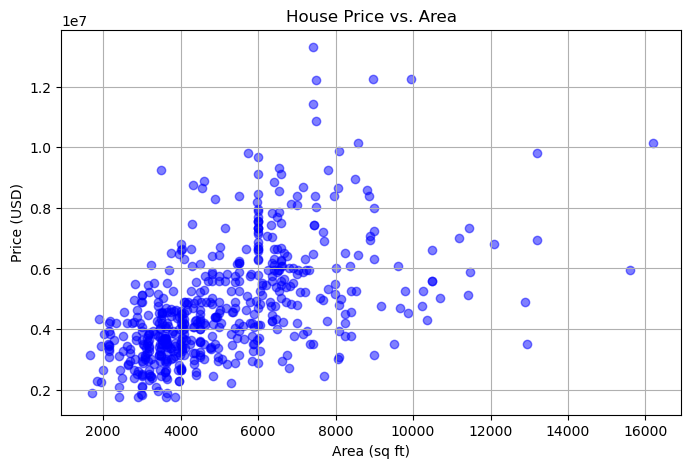

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 讀取 Housing.csv 資料
df = pd.read_csv('Housing.csv')

# 2. 建立畫布並設定圖表大小 (寬=8, 高=5)
plt.figure(figsize=(8, 5))

# 3. 繪製散佈圖 (x軸為面積，y軸為房價)
# alpha=0.5 代表設定半透明度，能看清點與點重疊的密集度
plt.scatter(df['area'], df['price'], color='blue', alpha=0.5)

# 4. 新增圖表標籤與標題
plt.title('House Price vs. Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (USD)')

# 5. 顯示網格與圖表
plt.grid(True)
plt.show()

# 範例 B：觀察「房價」的數據分佈區間（直方圖）
* 直方圖（Histogram）適合用來觀察單一數值欄位的次數分配，了解數據大多集中在什麼範圍、有沒有極端值。
* 函式：plt.hist(data, bins=組數)

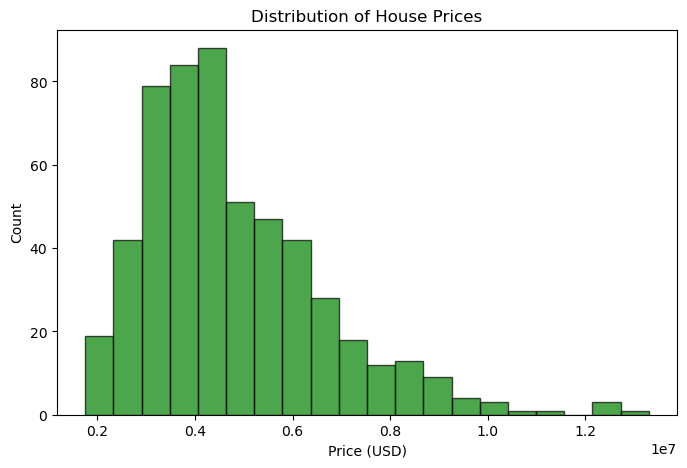

In [32]:
# 1. 建立畫布
plt.figure(figsize=(8, 5))

# 2. 繪製直方圖 (將房價分成 20 個區間)
# edgecolor='black' 可以幫每個長條圖加上黑邊，更容易辨識
plt.hist(df['price'], bins=20, color='green', edgecolor='black', alpha=0.7)

# 3. 新增標題與標籤
plt.title('Distribution of House Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')

# 4. 顯示圖表
plt.show()

# 範例 C：比較不同「裝潢狀態」的平均房價（長條圖）
* 長條圖（Bar Chart）適合用來比較不同「類別」之間的數值大小。
* 我們先用 Pandas 的 groupby() 計算出裝潢狀態（furnished / semi-furnished / unfurnished）的房價平均值，再交由 Matplotlib 畫圖。
* 函式：plt.bar(x, height)

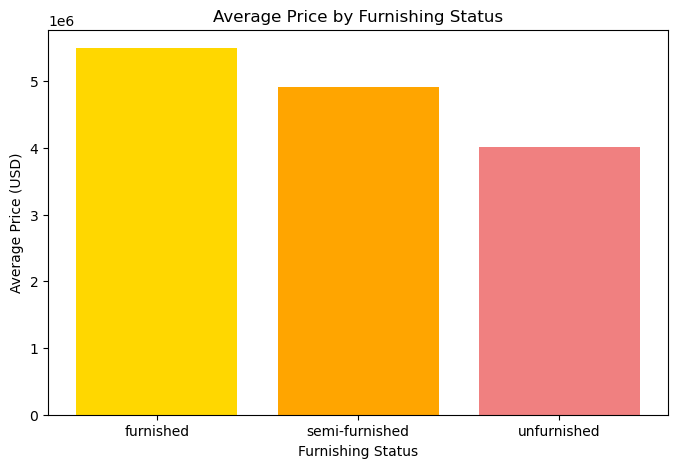

In [33]:
# 1. 使用 Pandas 計算各類裝潢狀態的平均房價
avg_price_by_status = df.groupby('furnishingstatus')['price'].mean()

# 2. 建立畫布
plt.figure(figsize=(8, 5))

# 3. 繪製長條圖
# x 軸為類別名稱 (index)，y 軸為平均價格 (values)
plt.bar(avg_price_by_status.index, avg_price_by_status.values, color=['gold', 'orange', 'lightcoral'])

# 4. 新增標題與標籤
plt.title('Average Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price (USD)')

# 5. 顯示圖表
plt.show()

# 補充觀念：解決中文顯示亂碼問題
* 預設情況下，Matplotlib 不支援中文字型，如果圖表標題寫中文（如：plt.title('房價分佈')）會變成方塊（亂碼）。
* 解決辦法：在程式碼最上方加入以下設定，指定使用系統中的中文字型（以微軟正黑體為例）：

In [34]:
# 解決中文字體不可顯示的問題
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei'] 
# 解決負號 '-' 無法正常顯示的問題
plt.rcParams['axes.unicode_minus'] = False